# Homework 4: Variational Autoencoder (from scratch)

## Extending HW3 DNN -> VAE

**Rules followed**
- Reuse the same HW2/HW3 dataset and preprocessing.
- Build two DNNs: one encoder and one decoder.
- Use a simple architecture because the dataset has only two features and 100 samples.
- Implement the complete VAE forward pass and backpropagation manually.
- Do not use any additional libraries beyond the HW3 allowed library set.
- Generate synthetic samples with the decoder and visualize real samples in red and fake samples in blue.
- Visualize the training loss curve.

### 1. Load Libraries and Data

The notebook expects `data (1).csv` to be in the same folder as the notebook, the same way HW3 loaded the uploaded dataset in Colab.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10, 6)
%matplotlib inline

In [ ]:
data = pd.read_csv("data (1).csv")
data.head()

,x1,x2,t
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1


In [ ]:
feature = data[["x1", "x2"]].values
class_label = data["t"].values

mean_scores = np.mean(feature, axis=0)
std_scores = np.std(feature, axis=0)
scores = (feature - mean_scores) / std_scores

X_vae = scores.T

print("Original feature shape:", feature.shape)
print("VAE input shape:", X_vae.shape)
print("Feature mean:", mean_scores)
print("Feature std:", std_scores)

Original feature shape: (100, 2)
VAE input shape: (2, 100)
Feature mean: [65.64427406 66.22199809]
Feature std: [19.36068671 18.48963567]


### 2. Visualize the Real Dataset

The VAE is trained as an unsupervised generative model, so the labels are not used during training. They are only used here to confirm that the reused HW3 data loaded correctly.

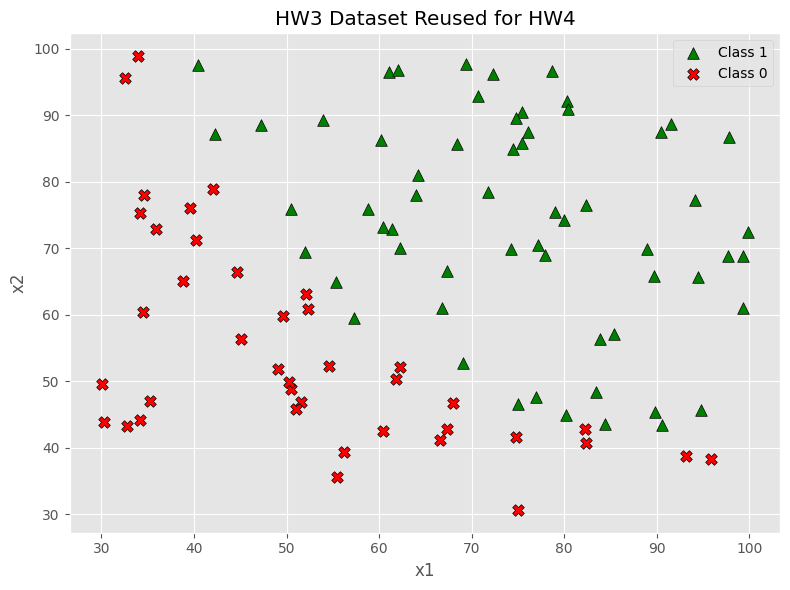

In [ ]:
class_1 = class_label == 1
class_0 = class_label == 0

plt.figure(figsize=(8, 6))
plt.scatter(feature[class_1, 0], feature[class_1, 1],
            marker="^", color="green", s=70, edgecolors="black", linewidths=0.5, label="Class 1")
plt.scatter(feature[class_0, 0], feature[class_0, 1],
            marker="X", color="red", s=70, edgecolors="black", linewidths=0.5, label="Class 0")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("HW3 Dataset Reused for HW4")
plt.legend()
plt.tight_layout()
plt.savefig("hw4_data_distribution.png", dpi=200)
plt.show()

---
## Part B: Variational Autoencoder (HW4)

**Architecture used**

Encoder: `Input(2) -> Hidden(8, Tanh) -> mu(2), logvar(2)`

Decoder: `Latent z(2) -> Hidden(8, Tanh) -> Reconstruction(2)`

The output layer is linear because the model reconstructs standardized continuous features, not class probabilities. The class labels are not used for training.

### 3. VAE Theory

The encoder maps a data point to the parameters of an approximate posterior distribution:

$$q_\phi(z|x) = N(\mu(x), diag(\sigma^2(x)))$$

The reparameterization trick makes sampling differentiable:

$$z = \mu + \exp(0.5 \cdot logvar) \odot \epsilon,\quad \epsilon \sim N(0, I)$$

The decoder maps the latent vector back to the data space:

$$\hat{x} = decoder_\theta(z)$$

The loss combines reconstruction error and KL divergence:

$$L = \frac{1}{m}\sum_i ||\hat{x}^{(i)} - x^{(i)}||^2
    + \beta \cdot \frac{1}{2m}\sum_i \sum_j
    (\exp(logvar_j^{(i)}) + \mu_j^{(i)2} - 1 - logvar_j^{(i)})$$

I used a small KL weight (`beta=0.05`) because this dataset is very small and simple. This keeps generated samples close to the real two-dimensional data distribution while still retaining the VAE regularization term.

### 4. Activation and Initialization

In [ ]:
def tanh_act(z):
    return np.tanh(z)


def tanh_deriv_from_activation(a):
    return 1 - a ** 2


def init_vae_params(seed=7, hidden_dim=8, latent_dim=2):
    # Simple VAE architecture:
    # encoder 2 -> 8 -> (mu=2, logvar=2)
    # decoder 2 -> 8 -> 2
    np.random.seed(seed)
    params = {
        "W_e1": np.random.randn(hidden_dim, 2) * np.sqrt(1.0 / 2),
        "b_e1": np.zeros((hidden_dim, 1)),
        "W_mu": np.random.randn(latent_dim, hidden_dim) * np.sqrt(1.0 / hidden_dim),
        "b_mu": np.zeros((latent_dim, 1)),
        "W_logvar": np.random.randn(latent_dim, hidden_dim) * np.sqrt(1.0 / hidden_dim),
        "b_logvar": np.zeros((latent_dim, 1)),
        "W_d1": np.random.randn(hidden_dim, latent_dim) * np.sqrt(1.0 / latent_dim),
        "b_d1": np.zeros((hidden_dim, 1)),
        "W_out": np.random.randn(2, hidden_dim) * np.sqrt(1.0 / hidden_dim),
        "b_out": np.zeros((2, 1))
    }
    return params

### 5. Forward Pass

In [ ]:
def encoder_forward(X, params):
    Z_e1 = params["W_e1"].dot(X) + params["b_e1"]
    H_e1 = tanh_act(Z_e1)
    mu = params["W_mu"].dot(H_e1) + params["b_mu"]
    logvar = params["W_logvar"].dot(H_e1) + params["b_logvar"]
    return mu, logvar, H_e1


def decoder_forward(z, params):
    Z_d1 = params["W_d1"].dot(z) + params["b_d1"]
    H_d1 = tanh_act(Z_d1)
    X_hat = params["W_out"].dot(H_d1) + params["b_out"]
    return X_hat, H_d1


def vae_forward(X, params, sample=True):
    mu, logvar, H_e1 = encoder_forward(X, params)
    std = np.exp(0.5 * logvar)

    if sample:
        eps = np.random.randn(*std.shape)
    else:
        eps = np.zeros(std.shape)

    z = mu + std * eps
    X_hat, H_d1 = decoder_forward(z, params)

    cache = {
        "H_e1": H_e1,
        "mu": mu,
        "logvar": logvar,
        "std": std,
        "eps": eps,
        "z": z,
        "H_d1": H_d1,
        "X_hat": X_hat
    }
    return X_hat, cache

### 6. VAE Loss Function

In [ ]:
def vae_loss(X, X_hat, mu, logvar, beta=0.05):
    reconstruction_loss = np.mean(np.sum((X_hat - X) ** 2, axis=0))
    kl_loss = 0.5 * np.mean(np.sum(np.exp(logvar) + mu ** 2 - 1 - logvar, axis=0))
    total_loss = reconstruction_loss + beta * kl_loss
    return total_loss, reconstruction_loss, kl_loss

### 7. Manual Backpropagation

The decoder gradients come first from the reconstruction error. The gradient is then passed through the sampled latent variable:

$$z = \mu + std \odot \epsilon$$

so the two encoder output gradients are:

$$d\mu = dz + \beta \frac{\mu}{m}$$

$$dlogvar = dz \odot (0.5 \cdot std \odot \epsilon)
       + \beta \frac{0.5}{m}(\exp(logvar) - 1)$$

The remaining gradients are ordinary chain-rule derivatives through the tanh encoder and decoder hidden layers.

In [ ]:
def vae_backward(X, params, cache, beta=0.05):
    m = X.shape[1]

    H_e1 = cache["H_e1"]
    mu = cache["mu"]
    logvar = cache["logvar"]
    std = cache["std"]
    eps = cache["eps"]
    z = cache["z"]
    H_d1 = cache["H_d1"]
    X_hat = cache["X_hat"]

    grads = {}

    # Reconstruction loss: mean squared error over samples.
    dX_hat = (2.0 / m) * (X_hat - X)

    # Decoder output layer.
    grads["W_out"] = dX_hat.dot(H_d1.T)
    grads["b_out"] = np.sum(dX_hat, axis=1, keepdims=True)

    # Decoder hidden layer.
    dH_d1 = params["W_out"].T.dot(dX_hat)
    dZ_d1 = dH_d1 * tanh_deriv_from_activation(H_d1)
    grads["W_d1"] = dZ_d1.dot(z.T)
    grads["b_d1"] = np.sum(dZ_d1, axis=1, keepdims=True)

    # Backpropagate into latent z.
    dz = params["W_d1"].T.dot(dZ_d1)

    # Reparameterization and KL gradients.
    dmu = dz + beta * (mu / m)
    dlogvar = dz * (0.5 * std * eps) + beta * (0.5 / m) * (np.exp(logvar) - 1)

    # Encoder output heads.
    grads["W_mu"] = dmu.dot(H_e1.T)
    grads["b_mu"] = np.sum(dmu, axis=1, keepdims=True)
    grads["W_logvar"] = dlogvar.dot(H_e1.T)
    grads["b_logvar"] = np.sum(dlogvar, axis=1, keepdims=True)

    # Shared encoder hidden layer.
    dH_e1 = params["W_mu"].T.dot(dmu) + params["W_logvar"].T.dot(dlogvar)
    dZ_e1 = dH_e1 * tanh_deriv_from_activation(H_e1)
    grads["W_e1"] = dZ_e1.dot(X.T)
    grads["b_e1"] = np.sum(dZ_e1, axis=1, keepdims=True)

    return grads

### 8. Training Loop

In [ ]:
def train_vae(X, lr=0.05, epochs=20000, beta=0.05, seed=7):
    np.random.seed(seed)
    params = init_vae_params(seed=seed, hidden_dim=8, latent_dim=2)
    history = {"epoch": [], "total": [], "reconstruction": [], "kl": []}

    for epoch in range(epochs + 1):
        X_hat, cache = vae_forward(X, params, sample=True)
        total_loss, reconstruction_loss, kl_loss = vae_loss(
            X, X_hat, cache["mu"], cache["logvar"], beta=beta
        )

        if epoch % 100 == 0:
            history["epoch"].append(epoch)
            history["total"].append(total_loss)
            history["reconstruction"].append(reconstruction_loss)
            history["kl"].append(kl_loss)

        if epoch == epochs:
            break

        grads = vae_backward(X, params, cache, beta=beta)
        for key in params:
            params[key] = params[key] - lr * grads[key]

    return params, history

In [ ]:
LEARNING_RATE = 0.05
EPOCHS = 12000
BETA = 0.05

params, history = train_vae(
    X_vae,
    lr=LEARNING_RATE,
    epochs=EPOCHS,
    beta=BETA,
    seed=7
)

X_recon, final_cache = vae_forward(X_vae, params, sample=False)
final_total, final_reconstruction, final_kl = vae_loss(
    X_vae, X_recon, final_cache["mu"], final_cache["logvar"], beta=BETA
)

print(f"Final deterministic total loss: {final_total:.6f}")
print(f"Final deterministic reconstruction loss: {final_reconstruction:.6f}")
print(f"Final deterministic KL loss: {final_kl:.6f}")

Final deterministic total loss: 0.181297
Final deterministic reconstruction loss: 0.002774
Final deterministic KL loss: 3.570453


### 9. Training Loss Curve

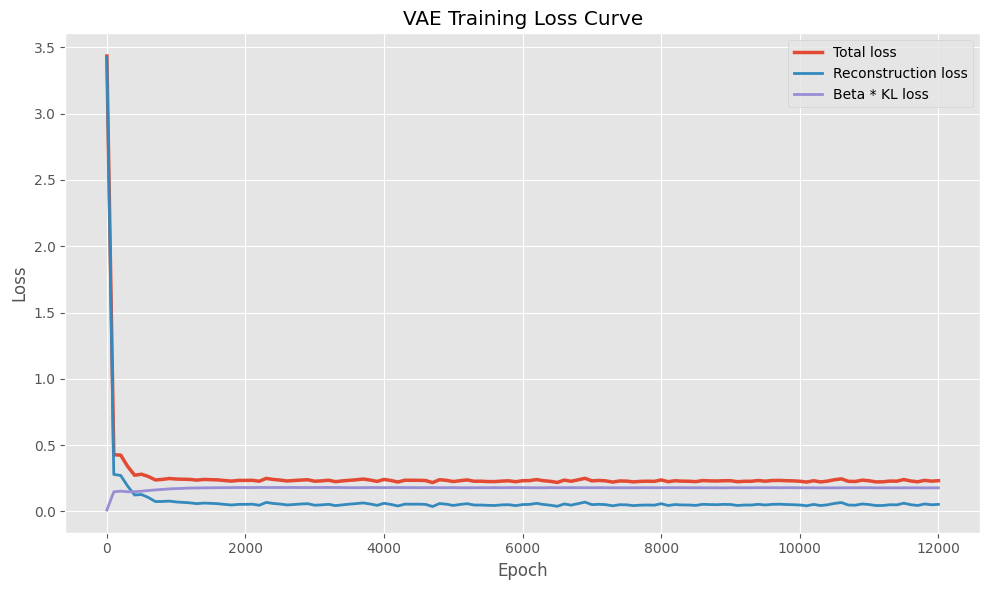

In [ ]:
history_df = pd.DataFrame(history)

plt.figure(figsize=(10, 6))
plt.plot(history_df["epoch"], history_df["total"], label="Total loss", linewidth=2.5)
plt.plot(history_df["epoch"], history_df["reconstruction"], label="Reconstruction loss", linewidth=2.0)
plt.plot(history_df["epoch"], BETA * history_df["kl"], label="Beta * KL loss", linewidth=2.0)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Loss Curve")
plt.legend()
plt.tight_layout()
plt.savefig("hw4_loss_curve.png", dpi=200)
plt.show()

### 10. Latent Space Visualization

This plot is not used for training. It shows how the encoder organizes the data in the two-dimensional latent space.

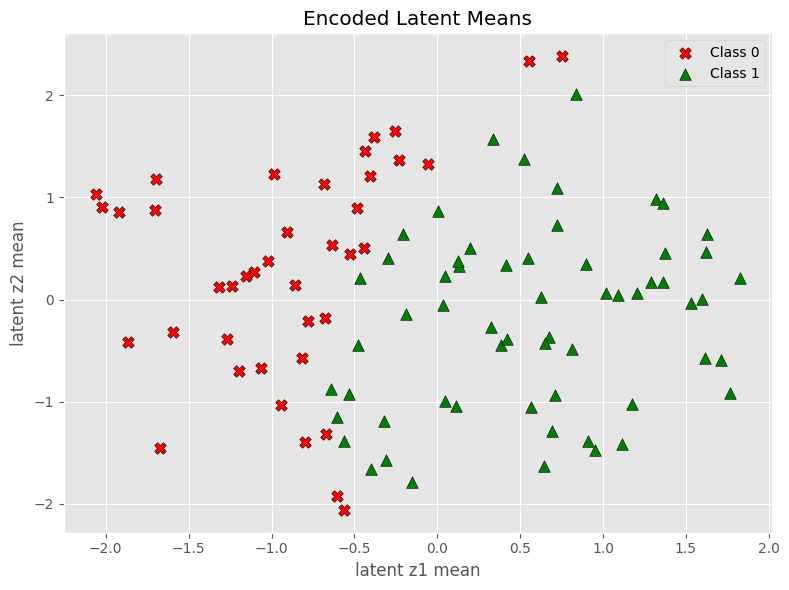

In [ ]:
mu, logvar, H_e1 = encoder_forward(X_vae, params)

plt.figure(figsize=(8, 6))
plt.scatter(mu[0, class_0], mu[1, class_0],
            color="red", marker="X", s=70, edgecolors="black", linewidths=0.4, label="Class 0")
plt.scatter(mu[0, class_1], mu[1, class_1],
            color="green", marker="^", s=70, edgecolors="black", linewidths=0.4, label="Class 1")
plt.xlabel("latent z1 mean")
plt.ylabel("latent z2 mean")
plt.title("Encoded Latent Means")
plt.legend()
plt.tight_layout()
plt.savefig("hw4_latent_space.png", dpi=200)
plt.show()

### 11. Generate Synthetic Samples with the Decoder

The decoder receives random latent vectors sampled from the VAE prior, `z ~ N(0, I)`. The decoded values are transformed back from standardized coordinates into the original `(x1, x2)` data space.

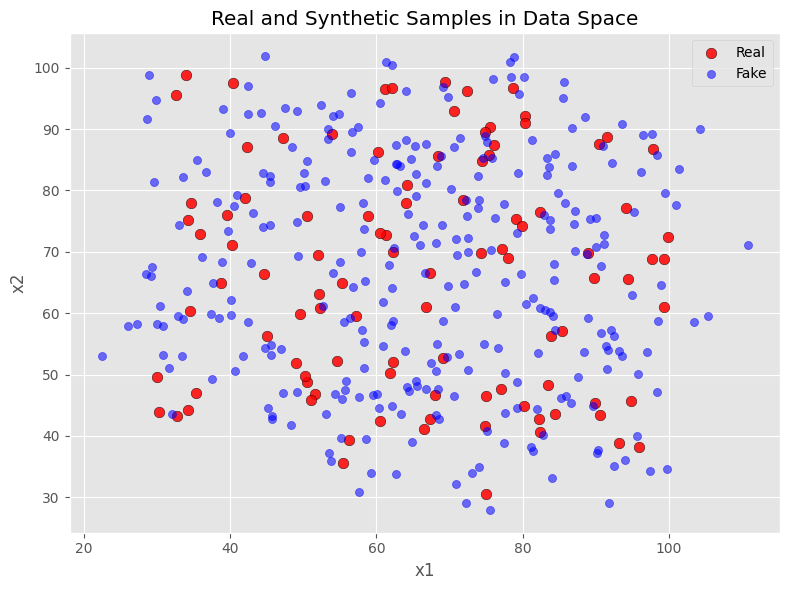

In [ ]:
np.random.seed(101)
num_fake = 300
z_prior = np.random.randn(2, num_fake)
fake_scores, _ = decoder_forward(z_prior, params)
fake_samples = fake_scores.T * std_scores + mean_scores

plt.figure(figsize=(8, 6))
plt.scatter(feature[:, 0], feature[:, 1],
            color="red", s=58, alpha=0.85, edgecolors="black", linewidths=0.35, label="Real")
plt.scatter(fake_samples[:, 0], fake_samples[:, 1],
            color="blue", s=34, alpha=0.55, label="Fake")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Real and Synthetic Samples in Data Space")
plt.legend()
plt.tight_layout()
plt.savefig("hw4_real_vs_synthetic.png", dpi=200)
plt.show()

### 12. Quantitative Summary

In [ ]:
real_mean = np.mean(feature, axis=0)
real_std = np.std(feature, axis=0)
fake_mean = np.mean(fake_samples, axis=0)
fake_std = np.std(fake_samples, axis=0)

summary = pd.DataFrame({
    "Metric": [
        "Architecture",
        "Latent dimension",
        "Epochs",
        "Learning rate",
        "Beta",
        "Final total loss",
        "Final reconstruction loss",
        "Final KL loss",
        "Real mean (x1, x2)",
        "Fake mean (x1, x2)",
        "Real std (x1, x2)",
        "Fake std (x1, x2)"
    ],
    "Value": [
        "Encoder 2-8-(mu/logvar), Decoder 2-8-2",
        "2",
        str(EPOCHS),
        str(LEARNING_RATE),
        str(BETA),
        f"{final_total:.6f}",
        f"{final_reconstruction:.6f}",
        f"{final_kl:.6f}",
        f"({real_mean[0]:.2f}, {real_mean[1]:.2f})",
        f"({fake_mean[0]:.2f}, {fake_mean[1]:.2f})",
        f"({real_std[0]:.2f}, {real_std[1]:.2f})",
        f"({fake_std[0]:.2f}, {fake_std[1]:.2f})"
    ]
})

summary.to_csv("hw4_metrics.csv", index=False)
pd.DataFrame(fake_samples, columns=["x1_fake", "x2_fake"]).to_csv("hw4_synthetic_samples.csv", index=False)
summary

,Metric,Value
0,Architecture,"Encoder 2-8-(mu/logvar), Decoder 2-8-2"
1,Latent dimension,2
2,Epochs,12000
3,Learning rate,0.05
4,Beta,0.05
5,Final total loss,0.181297
6,Final reconstruction loss,0.002774
7,Final KL loss,3.570453
8,"Real mean (x1, x2)","(65.64, 66.22)"
9,"Fake mean (x1, x2)","(66.40, 66.84)"


### 13. Final Comments

The VAE learns a compact probabilistic representation of the standardized two-dimensional data. The training loss decreases and stabilizes, and the generated decoder samples largely overlap the original data distribution in the `(x1, x2)` space. This satisfies the HW4 requirement to extend the HW3 DNN into an encoder-decoder VAE with manual backpropagation and synthetic-sample visualization.